In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/shehryar/Training'

csv_files = glob.glob(os.path.join(path, "*.csv"))

data_dict = {}
target_cols = ['B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()

        header_line = lines[7].lstrip(';').strip()
        data_lines = [line.strip() for line in lines[9:]]

        csv_content = "\n".join([header_line] + data_lines)

        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)

        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: road
  Successfully loaded road with shape: (69203, 4)


,B1,B2,B3,B4
0,246,260,194,226
1,244,258,192,221


Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 4)


,B1,B2,B3,B4
0,244,262,189,243
1,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 4)


...

Processing: water
  Successfully loaded water with shape: (386814, 4)


,B1,B2,B3,B4
0,235,251,186,185
1,236,250,187,177


Processing: urban
  Successfully loaded urban with shape: (495553, 4)


,B1,B2,B3,B4
0,298,332,261,263
1,305,343,271,272



Created 5 separate DataFrames.


In [14]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pandas as pd

all_dfs = []
MAX_PIXELS_PER_CLASS = 133000

print("Processing individual dataframes for pixel limit and class labeling...")
for class_name, df in data_dict.items():
    if len(df) > MAX_PIXELS_PER_CLASS:
        df_sampled = df.sample(n=MAX_PIXELS_PER_CLASS, random_state=42).copy() # Use random_state for reproducibility
        print(f"  Class '{class_name}' sampled from {len(df)} to {MAX_PIXELS_PER_CLASS} pixels.")
    else:
        df_sampled = df.copy()
        print(f"  Class '{class_name}' (size: {len(df)}) kept as is.")

    df_sampled['class'] = class_name
    all_dfs.append(df_sampled)

final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined final_df created with shape: {final_df.shape}")
print("First 5 rows of final_df with class labels (strings):")
display(final_df.head())

bands_df = final_df[['B1', 'B2', 'B3', 'B4']].copy()

B = bands_df['B1']
G = bands_df['B2']
R = bands_df['B3']
NIR = bands_df['B4']

bands_df['GNDVI'] = (NIR - G) / (NIR + G + 1e-6)

bands_df['EVI'] = 2.5 * ((NIR - R) / (NIR + 6 * R - 7.5 * B + 1 + 1e-6))

bands_df['SAVI'] = ((NIR - R) * (1 + 0.5)) / (NIR + R + 0.5 + 1e-6)

engineered_df = bands_df

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']

# StandardScaler is fit on the training split only (next cell),
# so validation and test pixels do not influence feature scale.
print(f"\nDataFrame after feature engineering (unscaled): {engineered_df.shape}")
print("First 5 rows of engineered_df:")
display(engineered_df.head())

engineered_df['class'] = final_df['class']

label_encoder = LabelEncoder()
engineered_df['class'] = label_encoder.fit_transform(engineered_df['class'])

print(f"\nFinal DataFrame with engineered features and INTEGER class labels: {engineered_df.shape}")
print("First 5 rows of the final engineered DataFrame:")
display(engineered_df.head())
print(f"\nMapping of original class names to integer labels: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Processing individual dataframes for pixel limit and class labeling...
  Class 'road' (size: 69203) kept as is.
  Class 'cpf-253' sampled from 133030 to 133000 pixels.
  Class 'sl-284' sampled from 232509 to 133000 pixels.
  Class 'water' sampled from 386814 to 133000 pixels.
  Class 'urban' sampled from 495553 to 133000 pixels.

Combined final_df created with shape: (601203, 5)
First 5 rows of final_df with class labels (strings):


,B1,B2,B3,B4,class
0,246,260,194,226,road
1,244,258,192,221,road
2,241,255,189,208,road
3,238,251,186,203,road
4,247,261,193,234,road



DataFrame after feature engineering (unscaled): (601203, 7)
First 5 rows of engineered_df:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,246,260,194,226,-0.069959,-0.176211,0.114150
1,244,258,192,221,-0.077244,-0.158991,0.105200
2,241,255,189,208,-0.101512,-0.102260,0.071698
3,238,251,186,203,-0.105727,-0.091398,0.065469
4,247,261,193,234,-0.054545,-0.223069,0.143860



Final DataFrame with engineered features and INTEGER class labels: (601203, 8)
First 5 rows of the final engineered DataFrame:


,B1,B2,B3,B4,GNDVI,EVI,SAVI,class
0,246,260,194,226,-0.069959,-0.176211,0.114150,1
1,244,258,192,221,-0.077244,-0.158991,0.105200,1
2,241,255,189,208,-0.101512,-0.102260,0.071698,1
3,238,251,186,203,-0.105727,-0.091398,0.065469,1
4,247,261,193,234,-0.054545,-0.223069,0.143860,1



Mapping of original class names to integer labels: [('cpf-253', np.int64(0)), ('road', np.int64(1)), ('sl-284', np.int64(2)), ('urban', np.int64(3)), ('water', np.int64(4))]


Split sizes -> train: 360721, val: 120241, test: 120241
Training on: cuda
Starting Grid Search for 8 combinations...
Each trial is trained on the training split and ranked by validation accuracy.
The test split is not used during this search.

Trial 1/8: {'dim_model': 32, 'nhead': 4, 'num_layers': 2}
  train_acc=0.8994  val_acc=0.9012

Trial 2/8: {'dim_model': 32, 'nhead': 4, 'num_layers': 3}
  train_acc=0.8983  val_acc=0.9016

Trial 3/8: {'dim_model': 32, 'nhead': 8, 'num_layers': 2}
  train_acc=0.8993  val_acc=0.8984

Trial 4/8: {'dim_model': 32, 'nhead': 8, 'num_layers': 3}
  train_acc=0.8982  val_acc=0.8962

Trial 5/8: {'dim_model': 64, 'nhead': 4, 'num_layers': 2}
  train_acc=0.8989  val_acc=0.9027

Trial 6/8: {'dim_model': 64, 'nhead': 4, 'num_layers': 3}
  train_acc=0.8976  val_acc=0.8986

Trial 7/8: {'dim_model': 64, 'nhead': 8, 'num_layers': 2}
  train_acc=0.8986  val_acc=0.8996

Trial 8/8: {'dim_model': 64, 'nhead': 8, 'num_layers': 3}
  train_acc=0.8976  val_acc=0.8985


,dim_model,nhead,num_layers,train_acc,val_acc,final_train_loss,val_precision,val_recall,val_f1-score,val_kappa
4,64,4,2,0.898897,0.902662,0.262368,0.903966,0.902662,0.903164,0.876907
1,32,4,3,0.898326,0.901639,0.266207,0.903726,0.901639,0.902114,0.875564
0,32,4,2,0.899371,0.901248,0.261988,0.902336,0.901248,0.901629,0.875071
6,64,8,2,0.898620,0.899618,0.262916,0.901527,0.899618,0.900305,0.873130
5,64,4,3,0.897638,0.898579,0.266742,0.899882,0.898579,0.899068,0.871833
7,64,8,3,0.897630,0.898537,0.266400,0.901281,0.898537,0.899447,0.871823
2,32,8,2,0.899313,0.898404,0.262439,0.901100,0.898404,0.898398,0.871425
3,32,8,3,0.898157,0.896233,0.266355,0.899646,0.896233,0.897348,0.868964



--- Important Things for Research Paper ---

Selected hyperparameters (highest validation accuracy):
  Number of transformer layers: 2
  Attention heads: 4
  Embedding dimension: 64
  Learning rate: 0.001
  Batch size: 128
  Validation accuracy used for selection: 0.9027

Retraining the selected configuration on train+val, then evaluating once on the held-out test set...

Important Metrics (Selected Model on Held-out Test Set):
  Accuracy: 0.9023
  Precision (weighted avg): 0.9041
  Recall (weighted avg): 0.9023
  F1-score (weighted avg): 0.9029
  Kappa score: 0.8765

Detailed Classification Report (Selected Model on Held-out Test Set):
              precision    recall  f1-score   support

     cpf-253       0.83      0.88      0.85     26600
        road       0.87      0.86      0.87     13841
      sl-284       0.86      0.85      0.86     26600
       urban       0.96      0.93      0.94     26600
       water       0.98      0.97      0.97     26600

    accuracy                

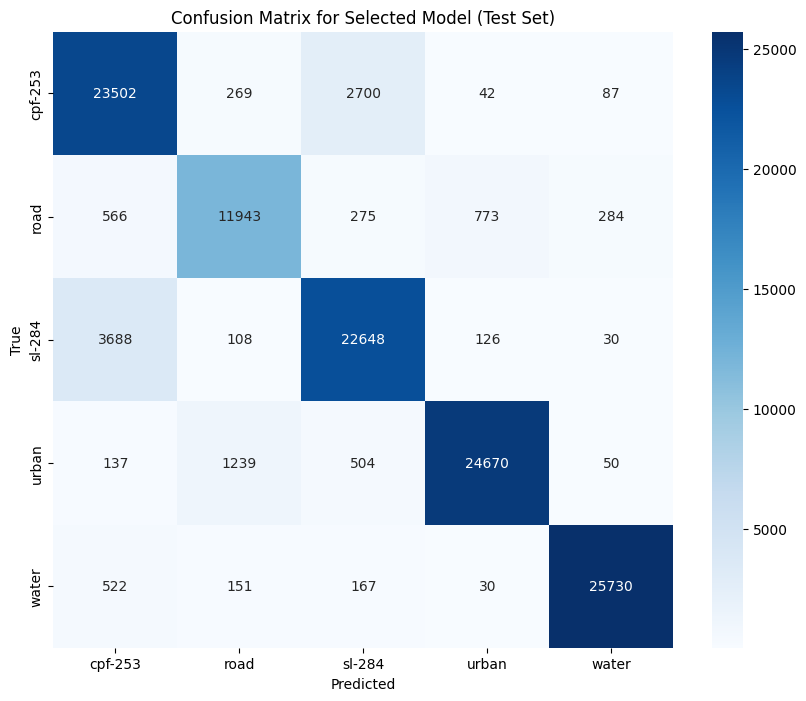


Important Tables:
Hyperparameter configuration table ranked by validation accuracy:


,dim_model,nhead,num_layers,train_acc,val_acc,final_train_loss,val_precision,val_recall,val_f1-score,val_kappa
4,64,4,2,0.898897,0.902662,0.262368,0.903966,0.902662,0.903164,0.876907
1,32,4,3,0.898326,0.901639,0.266207,0.903726,0.901639,0.902114,0.875564
0,32,4,2,0.899371,0.901248,0.261988,0.902336,0.901248,0.901629,0.875071
6,64,8,2,0.898620,0.899618,0.262916,0.901527,0.899618,0.900305,0.873130
5,64,4,3,0.897638,0.898579,0.266742,0.899882,0.898579,0.899068,0.871833
7,64,8,3,0.897630,0.898537,0.266400,0.901281,0.898537,0.899447,0.871823
2,32,8,2,0.899313,0.898404,0.262439,0.901100,0.898404,0.898398,0.871425
3,32,8,3,0.898157,0.896233,0.266355,0.899646,0.896233,0.897348,0.868964


In [15]:
import torch.nn as nn
import torch.optim as optim
import itertools
import pandas as pd
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

INPUT_DIM = len(feature_cols)
NUM_CLASSES = len(label_encoder.classes_)
LABEL_NAMES = label_encoder.classes_.tolist()

class TabularTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, dim_model=64, nhead=4, num_layers=2):
        super(TabularTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return self.fc(x)
FIXED_LR = 0.001
FIXED_BATCH_SIZE = 128 # Assuming this is used by your DataLoader

X = engineered_df[feature_cols].values
y = engineered_df['class'].values

TEST_SIZE = 0.2
VAL_SIZE_OF_TEMP = 0.25  # 0.25 of the remaining 80% -> 20% validation, 60% train
RANDOM_STATE = 42

# Hold out the test set first so it is never used during hyperparameter search.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VAL_SIZE_OF_TEMP, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Split sizes -> train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

# Fit the scaler on training pixels only, then apply the same transform to val/test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)
trainval_dataset = TensorDataset(
    torch.cat([X_train, X_val], dim=0),
    torch.cat([y_train, y_val], dim=0),
)

train_loader = DataLoader(train_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=False)
trainval_loader = DataLoader(trainval_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=True)

param_grid = {
    'dim_model': [32, 64],
    'nhead': [4, 8],
    'num_layers': [2, 3]
}

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

def evaluate_loader(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(
        all_labels, all_preds, target_names=LABEL_NAMES, output_dict=True, zero_division=0
    )
    kappa = cohen_kappa_score(all_labels, all_preds)
    return all_preds, all_labels, report, kappa


def train_model(params, data_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=int(params['dim_model']),
        nhead=int(params['nhead']),
        num_layers=int(params['num_layers'])
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    train_loss = 0
    correct_train = 0
    total_train = 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

    return model, correct_train / total_train, train_loss / len(data_loader)


def train_and_evaluate(params, train_loader, val_loader, num_epochs=5):
    # Train on the training split only. Score the trial on validation, never on test.
    model, train_acc, final_train_loss = train_model(params, train_loader, num_epochs=num_epochs)
    _, _, val_report, val_kappa = evaluate_loader(model, val_loader)

    return {
        **params,
        'train_acc': train_acc,
        'val_acc': val_report['accuracy'],
        'final_train_loss': final_train_loss,
        'val_precision': val_report['weighted avg']['precision'],
        'val_recall': val_report['weighted avg']['recall'],
        'val_f1-score': val_report['weighted avg']['f1-score'],
        'val_kappa': val_kappa,
    }

print(f"Starting Grid Search for {len(all_params)} combinations...")
print("Each trial is trained on the training split and ranked by validation accuracy.")
print("The test split is not used during this search.")
for i, params in enumerate(all_params):
    print(f"\nTrial {i+1}/{len(all_params)}: {params}")
    res = train_and_evaluate(params, train_loader, val_loader)
    results.append(res)
    print(f"  train_acc={res['train_acc']:.4f}  val_acc={res['val_acc']:.4f}")

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='val_acc', ascending=False))

print("\n--- Important Things for Research Paper ---")

best_result = results_df.sort_values(by='val_acc', ascending=False).iloc[0]
best_params = {
    'dim_model': int(best_result['dim_model']),
    'nhead': int(best_result['nhead']),
    'num_layers': int(best_result['num_layers'])
}

print("\nSelected hyperparameters (highest validation accuracy):")
print(f"  Number of transformer layers: {best_params['num_layers']}")
print(f"  Attention heads: {best_params['nhead']}")
print(f"  Embedding dimension: {best_params['dim_model']}")
print(f"  Learning rate: {FIXED_LR}")
print(f"  Batch size: {FIXED_BATCH_SIZE}")
print(f"  Validation accuracy used for selection: {best_result['val_acc']:.4f}")

print("\nRetraining the selected configuration on train+val, then evaluating once on the held-out test set...")
final_model, _, _ = train_model(best_params, trainval_loader, num_epochs=5)
test_preds, test_labels, test_report, test_kappa = evaluate_loader(final_model, test_loader)

print("\nImportant Metrics (Selected Model on Held-out Test Set):")
print(f"  Accuracy: {test_report['accuracy']:.4f}")
print(f"  Precision (weighted avg): {test_report['weighted avg']['precision']:.4f}")
print(f"  Recall (weighted avg): {test_report['weighted avg']['recall']:.4f}")
print(f"  F1-score (weighted avg): {test_report['weighted avg']['f1-score']:.4f}")
print(f"  Kappa score: {test_kappa:.4f}")

print("\nDetailed Classification Report (Selected Model on Held-out Test Set):")
final_report = classification_report(
    test_labels, test_preds,
    target_names=LABEL_NAMES, zero_division=0
)
print(final_report)

print("\nConfusion Matrix (Selected Model on Held-out Test Set):")
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Selected Model (Test Set)')
plt.show()

print("\nImportant Tables:")
print("Hyperparameter configuration table ranked by validation accuracy:")
display(results_df.sort_values(by='val_acc', ascending=False))

In [16]:
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.metrics import classification_report

INPUT_DIM = 7
NUM_CLASSES = 5
FIXED_LR = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class TabularTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, dim_model=64, nhead=4, num_layers=2):
        super(TabularTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return self.fc(x)

def train_model_for_permutation(params, train_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=params['dim_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    model.train()
    for epoch in range(num_epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model


best_result = results_df.sort_values(by='val_acc', ascending=False).iloc[0]
best_params = {
    'dim_model': int(best_result['dim_model']),
    'nhead': int(best_result['nhead']),
    'num_layers': int(best_result['num_layers'])
}

print(f"Using configuration selected by validation accuracy: {best_params}")
print(f"Validation accuracy: {best_result['val_acc']:.4f}")

# Reuse the already-trained final model when available; otherwise retrain on train+val.
if 'final_model' in globals():
    best_model = final_model
else:
    best_model = train_model_for_permutation(best_params, trainval_loader, num_epochs=5)

best_model.eval()
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for inputs, labels in trainval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

print("\nDetailed Classification Report (Selected Model on Train+Val Set):")
training_report = classification_report(
    all_train_labels, all_train_preds,
    target_names=LABEL_NAMES, zero_division=0
)
print(training_report)

Using configuration selected by validation accuracy: {'dim_model': 64, 'nhead': 4, 'num_layers': 2}
Validation accuracy: 0.9027

Detailed Classification Report (Selected Model on Train+Val Set):
              precision    recall  f1-score   support

     cpf-253       0.83      0.89      0.86    106400
        road       0.87      0.86      0.86     55362
      sl-284       0.86      0.85      0.86    106400
       urban       0.96      0.93      0.94    106400
       water       0.98      0.97      0.97    106400

    accuracy                           0.90    480962
   macro avg       0.90      0.90      0.90    480962
weighted avg       0.90      0.90      0.90    480962



Configuration selected by validation accuracy: {'dim_model': 64, 'nhead': 4, 'num_layers': 2}
Validation accuracy: 0.9027
Using the selected model already trained on train+val for permutation importance.
Held-out test accuracy used as permutation baseline: 0.9023

Calculating permutation importances...
  Feature 'B1': Importance = 0.4373
  Feature 'B2': Importance = 0.3905
  Feature 'B3': Importance = 0.4484
  Feature 'B4': Importance = 0.2236
  Feature 'GNDVI': Importance = 0.5165
  Feature 'EVI': Importance = 0.2624
  Feature 'SAVI': Importance = 0.3498

--- Feature Importance Table ---


,Feature,Importance
4,GNDVI,0.516504
2,B3,0.448383
0,B1,0.437272
1,B2,0.390549
6,SAVI,0.349806
5,EVI,0.262356
3,B4,0.223568


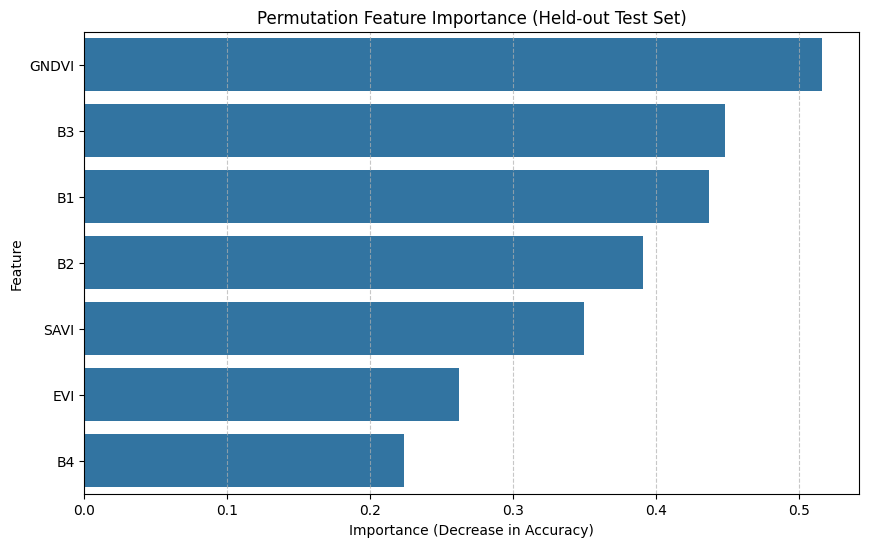

In [17]:
import torch.nn as nn
import torch.optim as optim
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

best_result = results_df.sort_values(by='val_acc', ascending=False).iloc[0]
best_params = {
    'dim_model': int(best_result['dim_model']),
    'nhead': int(best_result['nhead']),
    'num_layers': int(best_result['num_layers'])
}

print(f"Configuration selected by validation accuracy: {best_params}")
print(f"Validation accuracy: {best_result['val_acc']:.4f}")

def train_model_for_permutation(params, train_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=params['dim_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    model.train()
    for epoch in range(num_epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model

if 'final_model' in globals():
    print("Using the selected model already trained on train+val for permutation importance.")
    best_model = final_model
else:
    print("Retraining the selected configuration on train+val for permutation importance...")
    best_model = train_model_for_permutation(best_params, trainval_loader, num_epochs=5)

best_model.eval()
all_preds_baseline = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        all_preds_baseline.extend(predicted.cpu().numpy())

baseline_accuracy = accuracy_score(y_test.cpu().numpy(), all_preds_baseline)
print(f"Held-out test accuracy used as permutation baseline: {baseline_accuracy:.4f}")

feature_importances = {}
X_test_np = X_test.cpu().numpy() # Convert X_test to numpy for easier column shuffling
y_test_np = y_test.cpu().numpy()

print("\nCalculating permutation importances...")
for i, feature in enumerate(feature_cols):
    X_test_permuted_np = X_test_np.copy()
    np.random.shuffle(X_test_permuted_np[:, i])

    X_test_permuted_tensor = torch.tensor(X_test_permuted_np, dtype=torch.float32).to(device)

    permuted_preds = []
    permuted_dataset = TensorDataset(X_test_permuted_tensor, y_test.to(device))
    permuted_loader = DataLoader(permuted_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=False)

    with torch.no_grad():
        for inputs, _ in permuted_loader: # Labels are not used for accuracy calculation here, but for dataset
            outputs = best_model(inputs)
            _, predicted = outputs.max(1)
            permuted_preds.extend(predicted.cpu().numpy())

    permuted_accuracy = accuracy_score(y_test_np, permuted_preds)
    importance = baseline_accuracy - permuted_accuracy
    feature_importances[feature] = importance
    print(f"  Feature '{feature}': Importance = {importance:.4f}")

importance_df = pd.DataFrame(
    list(feature_importances.items()),
    columns=['Feature', 'Importance']
)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Table ---")
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Permutation Feature Importance (Held-out Test Set)')
plt.xlabel('Importance (Decrease in Accuracy)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()